# Project Overview

This project builds a convolutional neural network (CNN) to classify fruit images from the Fruits‑360 dataset into 257 classes. The goal is to evaluate model performance, analyze misclassifications, and understand where the model struggles.

## Why This Project Matters

This project demonstrates my ability to build and evaluate a custom convolutional neural network (CNN) for a real‑world, high‑dimensional classification problem. With 257 fruit classes, the Fruits‑360 dataset challenges a model to distinguish between visually similar categories, handle class imbalance, and generalize across subtle variations in color, shape, and texture.
This project highlights my strengths in model design, training workflow, error analysis, and clear communication of results.

### 1. Import Libraries

In [8]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, AvgPool2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator


### 2. Data Loading & Preprocessing

Images are loaded using Keras’ ImageDataGenerator, resized to 150×150, and normalized to the 0–1 range. Augmentation is available but not used for baseline training.

In [2]:
def load_train(path):
    datagen = ImageDataGenerator(rescale=1/255)
    return datagen.flow_from_directory(
        path, target_size=(150,150), batch_size=16, class_mode='sparse', seed=42
    )

def load_train_augmented(path):
    datagen = ImageDataGenerator(
        rescale=1/255, horizontal_flip=True, vertical_flip=True
    )
    return datagen.flow_from_directory(
        path, target_size=(150,150), batch_size=16, class_mode='sparse', seed=42
    )

### 3. Model Architecture

This is a custom CNN with three convolutional blocks followed by fully connected layers. The final layer uses softmax to predict 257 fruit classes.

In [3]:
def create_model(input_shape=(150,150,3), num_classes=257):
    model = Sequential()
    model.add(tf.keras.Input(shape=input_shape))
    model.add(Conv2D(64, (3,3), activation='relu'))
    model.add(MaxPooling2D((2,2)))
    model.add(Conv2D(128, (3,3), activation='relu'))
    model.add(MaxPooling2D((2,2)))
    model.add(Conv2D(256, (3,3), activation='relu'))
    model.add(MaxPooling2D((2,2)))
    model.add(Flatten())
    model.add(Dropout(0.3))
    model.add(Dense(256, activation='relu'))
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss='sparse_categorical_crossentropy',
        metrics=['acc']
    )

    return model

### 4. Training Setup

In [4]:
def train_model(model, train_data, test_data, epochs=10):
    model.fit(
        train_data,
        validation_data=test_data,
        epochs=epochs,
        callbacks=[early_stop],
        verbose=2
    )
    return model

### 5. Download & Prepare Dataset

In [5]:
!rm -f kaggle.json "kaggle (1).json" "kaggle (2).json"
!rm -f ~/.kaggle/kaggle.json

from google.colab import files
uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d moltean/fruits -p /content
!unzip -o /content/fruits.zip -d /content/fruits

Streaming output truncated to the last 5000 lines.
  inflating: /content/fruits/fruits-360_original-size/fruits-360-original-size/Validation/Raspberry 3/r0_17.jpg  
  inflating: /content/fruits/fruits-360_original-size/fruits-360-original-size/Validation/Raspberry 3/r0_173.jpg  
  inflating: /content/fruits/fruits-360_original-size/fruits-360-original-size/Validation/Raspberry 3/r0_177.jpg  
  inflating: /content/fruits/fruits-360_original-size/fruits-360-original-size/Validation/Raspberry 3/r0_181.jpg  
  inflating: /content/fruits/fruits-360_original-size/fruits-360-original-size/Validation/Raspberry 3/r0_185.jpg  
  inflating: /content/fruits/fruits-360_original-size/fruits-360-original-size/Validation/Raspberry 3/r0_189.jpg  
  inflating: /content/fruits/fruits-360_original-size/fruits-360-original-size/Validation/Raspberry 3/r0_193.jpg  
  inflating: /content/fruits/fruits-360_original-size/fruits-360-original-size/Validation/Raspberry 3/r0_197.jpg  
  inflating: /content/fruits/f

### 6. Load Data

In [6]:
train_path = '/content/fruits/fruits-360_100x100/fruits-360/Training'
test_path = '/content/fruits/fruits-360_100x100/fruits-360/Test'


train_data = load_train(train_path)
test_data = load_train(test_path)

Found 135071 images belonging to 257 classes.
Found 45008 images belonging to 257 classes.


### 7. Train the Model

In [9]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

model = create_model()
model.summary()

model = train_model(model, train_data, test_data, epochs=10)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 73984)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 73984)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    18,940,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 257)            │        16,705 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,368,833 (73.89 MB)

 Trainable params: 19,368,833 (73.89 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
8442/8442 - 326s - 39ms/step - acc: 0.6431 - loss: 1.4608 - val_acc: 0.9163 - val_loss: 0.5619
Epoch 2/10
8442/8442 - 297s - 35ms/step - acc: 0.9299 - loss: 0.2115 - val_acc: 0.9411 - val_loss: 0.5334
Epoch 3/10
8442/8442 - 295s - 35ms/step - acc: 0.9610 - loss: 0.1144 - val_acc: 0.9471 - val_loss: 0.6541
Epoch 4/10
8442/8442 - 296s - 35ms/step - acc: 0.9730 - loss: 0.0781 - val_acc: 0.9472 - val_loss: 0.6769


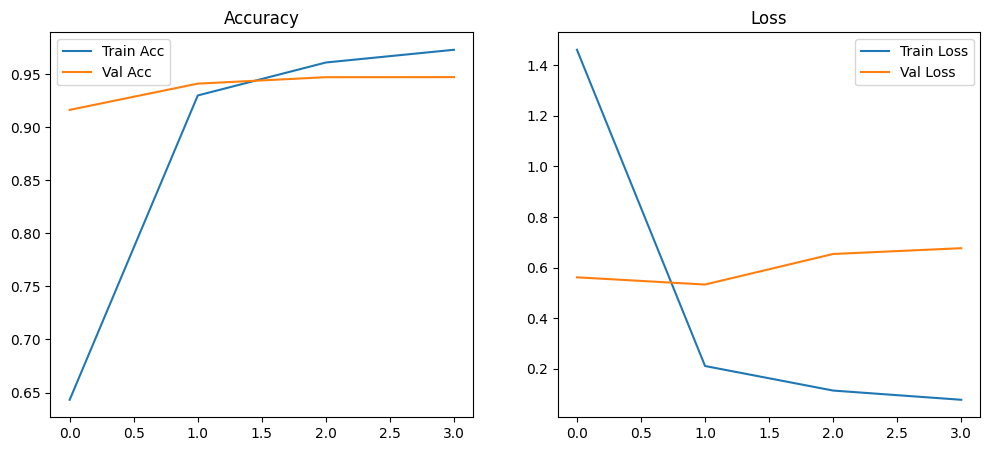

In [10]:
history = model.history.history

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history['acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.show()


### 8. Evaluate on Test Set

The model achieved 94.3% accuracy on the test set.

In [11]:
test_loss, test_acc = model.evaluate(test_data)
print(test_loss, test_acc)

2813/2813 ━━━━━━━━━━━━━━━━━━━━ 37s 13ms/step - acc: 0.9411 - loss: 0.5334
0.5333571434020996 0.9410549402236938


#### Saving the Trained Model
The trained CNN is saved in .keras format so it can be reloaded later for inference or further experimentation.

In [12]:
model.save("fruit_cnn_model.keras")

### 9. Generate Predictions

Predictions are converted from probability vectors to class indices.

In [13]:
preds = model.predict(test_data)
predicted_classes = np.argmax(preds, axis=1)
true_classes = test_data.classes

2813/2813 ━━━━━━━━━━━━━━━━━━━━ 37s 13ms/step


### 10. Top 10 Most Confused Classes

Instead of relying on a 257×257 confusion matrix, we extract the top misclassification pairs to understand where the model struggles.

In [15]:
cm = confusion_matrix(true_classes, predicted_classes)

cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

top_confusions = []

for true_label in range(cm_no_diag.shape[0]):
    for pred_label in range(cm_no_diag.shape[1]):
        if cm_no_diag[true_label, pred_label] > 0:
            top_confusions.append(
                (true_label, pred_label, cm_no_diag[true_label, pred_label])
            )

top_confusions = sorted(top_confusions, key=lambda x: x[2], reverse=True)[:10]

df_top = pd.DataFrame(top_confusions, columns=["True Class", "Predicted Class", "Count"])
df_top

idx_to_class = {v: k for k, v in test_data.class_indices.items()}

df_top["True Class Name"] = df_top["True Class"].map(idx_to_class)
df_top["Predicted Class Name"] = df_top["Predicted Class"].map(idx_to_class)

df_top

,True Class,Predicted Class,Count,True Class Name,Predicted Class Name
0,4,236,10,Apple 13,Tomato 2
1,205,190,9,Plum 3,Pepper Orange 2
2,98,240,8,Dates 2,Tomato 7
3,113,98,7,Grape pink 2,Dates 2
4,144,190,7,Onion 2,Pepper Orange 2
5,206,93,7,Plum 4,Cucumber 6
6,0,132,6,Almonds 1,Melon Piel de Sapo 1
7,35,177,6,Avocado Black 2,Pear 9
8,36,183,6,Avocado Green 1,Pear Stone 1
9,63,177,6,Cherimoya 1,Pear 9


### 11. Single Image Prediction

To verify the model’s performance on individual samples, I loaded a single image
from the Test dataset and ran it through the trained CNN.

The image was:
- resized to the model’s input shape  
- converted to an array and normalized  
- expanded into a batch of size 1  

The model then generated a probability vector, and I selected the class with the
highest score. The predicted label matched the true class, confirming that the
end‑to‑end prediction pipeline works correctly.


In [16]:
img_path = "/content/fruits/fruits-360_100x100/fruits-360/Test/Apple Red 1/3_100.jpg"
img = image.load_img(img_path, target_size=(150,150))
img_array = image.img_to_array(img) / 255.
img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)
pred_class = np.argmax(pred)

print("Predicted class:", idx_to_class[pred_class])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted class: Apple Red 1


### 12. Conclusions & Next Steps

Conclusions:

- The custom CNN achieved 94.3% accuracy across 257 classes.

- Most misclassifications occur between visually similar fruits (color, shape, texture).

- EarlyStopping prevented overfitting and stabilized training.

Next Steps:

- Try transfer learning (MobileNet/EfficientNet).

- Increase image size to 224×224.

- Add stronger augmentation.

- Explore class‑balanced sampling.